# Préparation des données – Contrats automobiles chez ENSAssuRances

ROY Tao

2026-03-29

## Introduction
Ce document présente le processus complet de préparation et de nettoyage des données issues de la base Contrat.

L’objectif de cette étape est de produire un jeu de données propre, cohérent et exploitable pour les analyses statistiques.

Les principales étapes de préparation sont :

- import et inspection initiale des données

- rennomage des colonnes

- nettoyage du contenu des variables qualitatives

- nettoyage du contenu des variables quantitatives

- Conversion des dates et tests de cohérences

- Détections et suppression des doublons

- analyse et traitement des valeurs manquantes

## 1. Chargement des librairies

Les bibliothèques suivantes sont utilisées pour la manipulation, la visualisation et le nettoyage des données :

In [ ]:
import pandas as pd
from itables import show
from pandas.api.types import CategoricalDtype
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import missingno as msno
import os

## 2. Importation des données

Les données sont importées depuis un fichier xlsx.

In [9]:
df_brut = pd.read_excel("data/Contrat.xlsx")

On fait une inspection de la table chargée :

In [10]:
show(df_brut.head(100), 
     scrollX=True, 
     lengthMenu=[5, 10, 25, 50], 
     pageLength=5,
     classes="cell-border stripe")

Loading ITables v2.7.3 from the internet... (need help?)


In [11]:
print(f"Dimensions : {df_brut.shape}") # (Lignes, Colonnes)
print("-" * 30)
df_brut.info()
display(df_brut.head(3).T) # Aperçu transposé des 3 premières lignes

Dimensions : (301437, 40)
------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 301437 entries, 0 to 301436
Data columns (total 40 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   idxCt                 301437 non-null  str    
 1   idxYear               301437 non-null  int64  
 2   vhImmat               301437 non-null  str    
 3   sitStartDate          301437 non-null  str    
 4   sitEndDate            301437 non-null  str    
 5   sitExpo               301437 non-null  float64
 6   drv1Age               301437 non-null  float64
 7   drv1Sex               301437 non-null  str    
 8   drv1DriveLicenceType  301437 non-null  str    
 9   drv1DriveLicenceAge   301437 non-null  float64
 10  vhAge                 301437 non-null  float64
 11  ctFrm                 301437 non-null  str    
 12  ctAssBase             301437 non-null  int64  
 13  ctAss0km              301437 non-null  int64  
 14  ctAssV

,0,1,2
idxCt,C002513884,C002513884,C002513884
idxYear,2019,2020,2021
vhImmat,ME-6556-LY,ME-6556-LY,ME-6556-LY
sitStartDate,2019-01-01,2020-01-01,2021-01-01
sitEndDate,2019-12-31,2020-12-31,2021-12-31
sitExpo,1.0,1.0,1.0
drv1Age,39.52,40.52,41.52
drv1Sex,H,H,H
drv1DriveLicenceType,Cond Accompagnée,Cond Accompagnée,Cond Accompagnée
drv1DriveLicenceAge,18.68,19.68,20.68


## 3. Rennomage des colonnes

Pour une utilisation plus simple de la donnée on va modifier le nom des colonnes comme ceci :

In [109]:
# Création du dictionnaire complet pour les 40 variables de la table Contrats
data_contrats_complet = {
    "Nom d'origine": [
        "idxCt", "idxYear", "vhImmat", "sitStartDate", "sitEndDate", "sitExpo", "drv1Age", "drv1Sex", 
        "drv1DriveLicenceType", "drv1DriveLicenceAge", "vhAge", "ctFrm", "ctAssBase", "ctAss0km", 
        "ctAssVHR", "vhSegment", "vhMarque", "vhEnergy", "vhWeight", "vhDIN", "vhValue", "vhGroup", 
        "vhClass", "ctUsage", "ctKM", "ctDeduc", "claimsAnt", "ctINSEE", "id1_AssBase", "id1_Ass0km", 
        "id1_AssVHR", "id2_AssBase", "id2_Ass0km", "id2_AssVHR", "id3_AssBase", "id3_Ass0km", 
        "id3_AssVHR", "COT_AssBase", "COT_Ass0km", "COT_AssVHR"
    ],
    "Nouveau nom": [
        "id_contrat", "annee_exercice", "immatriculation", 'date_debut_situation', 'date_fin_situation', "exposition_risque", "age_conducteur", "genre_conducteur",
        "permis_type", "anciennete_permis", "age_vehicule", "formule_contrat", "garantie_assistance_base", "garantie_assistance_0km",
       "garantie_assistance_vhr", "vehicule_segment", "vehicule_marque", "vehicule_energie", "vehicule_poids", "vehicule_puissance_din", "vehicule_valeur", "vehicule_groupe",
        "vehicule_classe", "usage_contrat", "option_petit_rouleur", 'franchise_montant','nb_sinistres_anterieurs', "code_insee_commune", "id1_sinistre_base", "id1_sinistre_0km",
        "id1_sinistre_vhr", "id2_sinistre_base", "id2_sinistre_0km", "id2_sinistre_vhr", "id3_sinistre_base", "id3_sinistre_0km",
        "id3_sinistre_vhr", "cotisation_base", "cotisation_0km", "cotisation_vhr"
    ],
    "Type": [
        "texte", "entier", "texte", "texte", "texte", "decimal", "decimal", "texte", 
        "texte", "decimal", "decimal", "texte", "entier", "entier", 
        "entier", "texte", "texte", "texte", "entier", "entier", "decimal", "texte", 
        "texte", "texte", "texte", "entier", "entier", "texte", "texte", "texte", 
        "texte", "texte", "texte", "texte", "texte", "texte", 
        "texte", "decimal", "decimal", "decimal"
    ],
    "Description": [
        "Identifiant contrat", "Exercice", "Immatriculation du véhicule", "Date de début de la situation", "Date de fin de la situation", "Exposition de la situation", "Age du conducteur principal", "Genre du conducteur principal",
        "Mode d'obtention du permis", "Ancienneté du permis", "Age du véhicule", "Formule souscrite au contrat", "Assistance de Base (1/0)", "Assistance 0 km (1/0)",
        "Assistance Véhicule de Remplacement (1/0)", "Segment commercial du véhicule", "Marque du véhicule", "Alimentation du véhicule", "Poids du véhicule", "Puissance DIN du véhicule", "Valeur du véhicule", "Groupe du véhicule",
        "Classe du véhicule", "Usage déclaré au contrat", "Option Petit Rouleur", "Franchise souscrite", "Nombre de sinistres antérieurs", "Code INSEE de la commune", "ID sinistre Assistance Base n°1", "ID sinistre Assistance 0km n°1",
        "ID sinistre Assistance VHR n°1", "ID sinistre Assistance Base n°2", "ID sinistre Assistance 0km n°2", "ID sinistre Assistance VHR n°2", "ID sinistre Assistance Base n°3", "ID sinistre Assistance 0km n°3",
        "ID sinistre Assistance VHR n°3", "Cotisation payée Assistance Base", "Cotisation payée Assistance 0km", "Cotisation payée Assistance VHR"
    ]
}

df_dico_complet = pd.DataFrame(data_contrats_complet)

# Affichage élégant
print("DICTIONNAIRE COMPLET DES DONNÉES - CONTRATS (40 VARIABLES)")
display(df_dico_complet)

DICTIONNAIRE COMPLET DES DONNÉES - CONTRATS (40 VARIABLES)


,Nom d'origine,Nouveau nom,Type,Description
0,idxCt,id_contrat,texte,Identifiant contrat
1,idxYear,annee_exercice,entier,Exercice
2,vhImmat,immatriculation,texte,Immatriculation du véhicule
3,sitStartDate,date_debut_situation,texte,Date de début de la situation
4,sitEndDate,date_fin_situation,texte,Date de fin de la situation
5,sitExpo,exposition_risque,decimal,Exposition de la situation
6,drv1Age,age_conducteur,decimal,Age du conducteur principal
7,drv1Sex,genre_conducteur,texte,Genre du conducteur principal
8,drv1DriveLicenceType,permis_type,texte,Mode d'obtention du permis
9,drv1DriveLicenceAge,anciennete_permis,decimal,Ancienneté du permis


In [47]:
# Dictionnaire de renommage strict basé sur le dictionnaire des données 
mapping_contrats = {
    "idxCt": "id_contrat",
    "idxYear": "annee_exercice",
    "vhImmat": "immatriculation",
    "sitStartDate": "date_debut_sit",
    "sitEndDate": "date_fin_sit",
    "sitExpo": "exposition",
    "drv1Age": "age_conducteur",
    "drv1Sex": "genre_conducteur",
    "drv1DriveLicenceType": "type_permis",
    "drv1DriveLicenceAge": "anciennete_permis",
    "vhAge": "age_vehicule",
    "ctFrm": "formule_contrat",
    "ctAssBase": "garantie_base",
    "ctAss0km": "garantie_0km",
    "ctAssVHR": "garantie_vhr",
    "vhSegment": "vehicule_segment",
    "vhMarque": "vehicule_marque",
    "vhEnergy": "vehicule_energie",
    "vhWeight": "vehicule_poids",
    "vhDIN": "puissance_din",
    "vhValue": "valeur_vehicule",
    "vhGroup": "groupe_vehicule",
    "vhClass": "classe_vehicule",
    "ctUsage": "usage_contrat",
    "ctKM": "option_km",
    "ctDeduc": "franchise",
    "claimsAnt": "nb_sinistres_ant",
    "ctINSEE": "code_insee",
    "id1_AssBase": "id1_sinistre_base",
    "id1_Ass0km": "id1_sinistre_0km",
    "id1_AssVHR": "id1_sinistre_vhr",
    "id2_AssBase": "id2_sinistre_base",
    "id2_Ass0km": "id2_sinistre_0km",
    "id2_AssVHR": "id2_sinistre_vhr",
    "id3_AssBase": "id3_sinistre_base",
    "id3_Ass0km": "id3_sinistre_0km",
    "id3_AssVHR": "id3_sinistre_vhr",
    "COT_AssBase": "cotisation_base",
    "COT_Ass0km": "cotisation_0km",
    "COT_AssVHR": "cotisation_vhr"
}

# Application du renommage
df_prep = df_brut.rename(columns=mapping_contrats)

Nouveaux noms des 40 colonnes :

In [20]:
df_prep.columns

Index(['id_contrat', 'annee_exercice', 'immatriculation',
       'date_debut_situation', 'date_fin_situation', 'exposition_risque',
       'age_conducteur', 'genre_conducteur', 'permis_type',
       'anciennete_permis', 'age_vehicule', 'formule_contrat',
       'garantie_assistance_base', 'garantie_assistance_0km',
       'garantie_assistance_vhr', 'vehicule_segment', 'vehicule_marque',
       'vehicule_energie', 'vehicule_poids', 'vehicule_puissance_din',
       'vehicule_valeur', 'vehicule_groupe', 'vehicule_classe',
       'usage_contrat', 'option_petit_rouleur', 'franchise_montant',
       'nb_sinistres_anterieurs', 'code_insee_commune', 'id1_sinistre_base',
       'id1_sinistre_0km', 'id1_sinistre_vhr', 'id2_sinistre_base',
       'id2_sinistre_0km', 'id2_sinistre_vhr', 'id3_sinistre_base',
       'id3_sinistre_0km', 'id3_sinistre_vhr', 'cotisation_base',
       'cotisation_0km', 'cotisation_vhr'],
      dtype='str')

## 4. Nettoyage du contenu des variables qualitatives

### 4.1 Normalisation de la colonne immatriculation

In [25]:
# Nombre total de lignes vs nombre d'immatriculations uniques
total_lignes = len(df_prep)
uniques = df_prep['immatriculation'].nunique()

print(f"Total lignes : {total_lignes}")
print(f"Immatriculations uniques : {uniques}")

Total lignes : 301437
Immatriculations uniques : 69686


On regarde si toute les plaques sont bien noté au bon format :

In [24]:
# On cherche ce qui ne ressemble pas à du texte avec des tirets
format_incorrect = df_prep[~df_prep['immatriculation'].str.contains(r'[A-Z]{2}-\d+-?[A-Z]{2}', na=False, regex=True)]

print(f"Nombre de lignes au format suspect : {len(format_incorrect)}")
display(format_incorrect['immatriculation'].head())

Nombre de lignes au format suspect : 0


Series([], Name: immatriculation, dtype: str)

### 4.2 Normalisation de la colonne genre_conducteur

In [26]:
df_prep['genre_conducteur'].value_counts()

genre_conducteur
H    180200
F    121237
Name: count, dtype: int64

On voit que l'on a bien nos 2 catégories cependant on va changer le nom des valeurs pour qu'elles soient plus explicite :

In [123]:
mapping_genre = {
    "H": "Homme",
    "F": "Femme"
}

# Application de la transformation
df_prep['genre_conducteur'] = df_prep['genre_conducteur'].replace(mapping_genre)

# Vérification du nouveau "table()"
print(df_prep['genre_conducteur'].value_counts())

genre_conducteur
Homme    180200
Femme    121237
Name: count, dtype: int64


On transforme aussi la variable en catégorie.

In [31]:
df_prep['genre_conducteur'] = df_prep['genre_conducteur'].astype('category')

### 4.3 Normalisation de la colonne permis_type

In [29]:
df_prep['permis_type'].value_counts()

permis_type
Traditionnel        226920
Cond Accompagnée     74517
Name: count, dtype: int64

On voit que l'on a bien nos 2 catégories cependant on va changer le nom des valeurs pour qu'elles soient plus explicite :

In [30]:
mapping_type = {
    "Traditionnel": "Traditionnel",
    "Cond Accompagnée": "Conduite Accompagnée"
}

# Application de la transformation
df_prep['permis_type'] = df_prep['permis_type'].replace(mapping_type)

# Vérification du nouveau "table()"
print(df_prep['permis_type'].value_counts())

permis_type
Traditionnel            226920
Conduite Accompagnée     74517
Name: count, dtype: int64


On transforme aussi la variable en catégorie.

In [32]:
df_prep['permis_type'] = df_prep['permis_type'].astype('category')

### 4.4 Normalisation de la colonne formule_contrat

In [33]:
df_prep['formule_contrat'].value_counts()

formule_contrat
Mini    192558
Maxi     59441
Med1     25480
Med2     23958
Name: count, dtype: int64

On a bien toute nos catégories que l'on transorme en catégorie et que l'on place dans l'ordre.

In [36]:
niveau_formules = CategoricalDtype(
    categories=['Mini', 'Med1', 'Med2', 'Maxi'], 
    ordered=True
)

# On applique la transformation
df_prep['formule_contrat'] = df_prep['formule_contrat'].astype(niveau_formules)

### 4.5 Normalisation de la colonne vehicule_segment

In [37]:
df_prep['vehicule_segment'].value_counts()

vehicule_segment
Citadine     120614
Familiale     75566
Compacte      59953
SUV           45304
Name: count, dtype: int64

On transforme la variable en catégorie.

In [38]:
df_prep['vehicule_segment'] = df_prep['vehicule_segment'].astype('category')

### 4.6 Normalisation de la colonne vehicule_marque

In [39]:
df_prep['vehicule_marque'].value_counts()

vehicule_marque
Renault          60970
Citroen          60461
Peugeot          59382
Autre            29975
Nissan            9353
Seat              9231
Audi              9148
Mercedes Benz     9099
Toyota            9079
Dacia             9053
Fiat              8995
BMW               8987
Ford              8870
Volkswagen        8834
Name: count, dtype: int64

On transforme la variable en catégorie.

In [40]:
df_prep['vehicule_marque'] = df_prep['vehicule_marque'].astype('category')

### 4.7 Normalisation de la colonne vehicule_energie

In [41]:
df_prep['vehicule_energie'].value_counts()

vehicule_energie
Essence               135559
Diesel                120352
Electrique/Hybride     45526
Name: count, dtype: int64

On transforme la variable en catégorie.

In [42]:
df_prep['vehicule_marque'] = df_prep['vehicule_marque'].astype('category')

### 4.9 Normalisation de la colonne classe_vehicule

In [52]:
df_prep['vehicule_classe'].value_counts()

vehicule_classe
3    141403
2     94569
4     54106
5      6512
1      4847
Name: count, dtype: int64

On transforme la variable en catégorie.

In [53]:
df_prep['vehicule_classe'] = df_prep['vehicule_classe'].astype('category')

### 4.10 Normalisation de la colonne usage_contrat

In [54]:
df_prep['usage_contrat'].value_counts()

usage_contrat
Pri    241594
Pro     59843
Name: count, dtype: int64

On voit que l'on a bien nos 2 catégories cependant on va changer le nom des valeurs pour qu'elles soient plus explicite :

In [55]:
mapping_usage = {
    "Pri": "Privé",
    "Pro": "professionnelle"
}

# Application de la transformation
df_prep['usage_contrat'] = df_prep['usage_contrat'].replace(mapping_usage)

# Vérification du nouveau "table()"
print(df_prep['usage_contrat'].value_counts())

usage_contrat
Privé              241594
professionnelle     59843
Name: count, dtype: int64


On transforme la variable en catégorie.

In [56]:
df_prep['usage_contrat'] = df_prep['usage_contrat'].astype('category')

### 4.11 Normalisation de la colonne option_petit_rouleur

In [58]:
df_prep['option_petit_rouleur'].value_counts()

option_petit_rouleur
N    260973
O     40464
Name: count, dtype: int64

On voit que l'on a bien nos 2 catégories cependant on va changer le nom des valeurs pour qu'elles soient plus explicite :

In [59]:
mapping_option = {
    "N": "Non",
    "O": "Oui"
}

# Application de la transformation
df_prep['option_petit_rouleur'] = df_prep['option_petit_rouleur'].replace(mapping_option)

# Vérification du nouveau "table()"
print(df_prep['option_petit_rouleur'].value_counts())

option_petit_rouleur
Non    260973
Oui     40464
Name: count, dtype: int64


On transforme la variable en catégorie.

In [61]:
df_prep['option_petit_rouleur'] = df_prep['option_petit_rouleur'].astype('category')

### 4.12 Normalisation de la colonne garantie_assistance_base

In [66]:
df_prep['garantie_assistance_base'].value_counts()

garantie_assistance_base
1    301437
Name: count, dtype: int64

On voit que l'on a bien nos 2 catégories cependant on va changer le nom des valeurs pour qu'elles soient plus explicite :

In [70]:
mapping_base = {
    1 : "Présence",
    0 : "absence"
}

# Application de la transformation
df_prep['garantie_assistance_base'] = df_prep['garantie_assistance_base'].replace(mapping_base)

# Vérification du nouveau "table()"
print(df_prep['garantie_assistance_base'].value_counts())

garantie_assistance_base
Présence    301437
Name: count, dtype: int64


On transforme la variable en catégorie.

In [78]:
df_prep['garantie_assistance_base'] = df_prep['garantie_assistance_base'].astype('category')

### 4.13 Normalisation de la colonne garantie_assistance_0km

In [67]:
df_prep['garantie_assistance_0km'].value_counts()

garantie_assistance_0km
0    265882
1     35555
Name: count, dtype: int64

On voit que l'on a bien nos 2 catégories cependant on va changer le nom des valeurs pour qu'elles soient plus explicite :

In [72]:
mapping_okm = {
    1 : "Présence",
    0 : "absence"
}

# Application de la transformation
df_prep['garantie_assistance_0km'] = df_prep['garantie_assistance_0km'].replace(mapping_okm)

# Vérification du nouveau "table()"
print(df_prep['garantie_assistance_0km'].value_counts())

garantie_assistance_0km
absence     265882
Présence     35555
Name: count, dtype: int64


On transforme la variable en catégorie.

In [77]:
df_prep['garantie_assistance_0km'] = df_prep['garantie_assistance_0km'].astype('category')

### 4.14 Normalisation de la colonne garantie_assistance_vhr

In [68]:
df_prep['garantie_assistance_vhr'].value_counts()

garantie_assistance_vhr
0    282195
1     19242
Name: count, dtype: int64

On voit que l'on a bien nos 2 catégories cependant on va changer le nom des valeurs pour qu'elles soient plus explicite :

In [73]:
mapping_vhr = {
    1 : "Présence",
    0 : "absence"
}

# Application de la transformation
df_prep['garantie_assistance_vhr'] = df_prep['garantie_assistance_vhr'].replace(mapping_vhr)

# Vérification du nouveau "table()"
print(df_prep['garantie_assistance_vhr'].value_counts())

garantie_assistance_vhr
absence     282195
Présence     19242
Name: count, dtype: int64


On transforme la variable en catégorie.

In [76]:
df_prep['garantie_assistance_vhr'] = df_prep['garantie_assistance_vhr'].astype('category')

## 5. Nettoyage du contenu des variables quantitatives

Maintenant nous allons travailler sur les problème de cohérence et de valeur abberante sur les variables numérique.

#### Voici les informations que nous avons concernant les différentes variables :

In [105]:
# Sélection de tes variables numériques spécifiques
cols_numeriques = [
    'exposition_risque', 'age_conducteur', "anciennete_permis", "age_vehicule", 
    "vehicule_poids", "vehicule_puissance_din", "vehicule_valeur", 
    'franchise_montant','nb_sinistres_anterieurs', 
    "cotisation_base", "cotisation_0km", "cotisation_vhr", 'annee_exercice'
]

diagnostic_num = df_prep[cols_numeriques]

print("RÉSUMÉ STATISTIQUE DES VARIABLES NUMÉRIQUES")
display(diagnostic_num.describe().T)

# Vérification des valeurs manquantes
print("\nVALEURS MANQUANTES (NA) :")
print(diagnostic_num.isnull().sum())

RÉSUMÉ STATISTIQUE DES VARIABLES NUMÉRIQUES


,count,mean,std,min,25%,50%,75%,max
exposition_risque,301437.0,0.966932,0.144753,0.002732,1.00,1.00,1.00,1.00
age_conducteur,301437.0,44.693525,13.685469,18.500000,33.87,43.82,54.57,79.00
anciennete_permis,301437.0,24.737300,13.659565,0.000000,13.86,23.85,34.58,60.86
age_vehicule,301437.0,11.485966,4.879809,0.000000,8.18,11.64,14.96,24.00
vehicule_poids,301437.0,1387.545716,308.583216,600.000000,1171.00,1385.00,1599.00,2793.00
vehicule_puissance_din,301437.0,132.558810,47.501897,50.000000,96.00,129.00,164.00,300.00
vehicule_valeur,301437.0,11466.762802,6107.463141,1476.010000,6739.61,10588.37,15178.55,43975.97
franchise_montant,301437.0,289.778959,104.144356,200.000000,200.00,200.00,400.00,500.00
nb_sinistres_anterieurs,301437.0,0.396312,0.660379,0.000000,0.00,0.00,1.00,2.00
cotisation_base,301437.0,46.109888,18.453072,0.050000,32.28,45.51,61.00,120.62



VALEURS MANQUANTES (NA) :
exposition_risque          0
age_conducteur             0
anciennete_permis          0
age_vehicule               0
vehicule_poids             0
vehicule_puissance_din     0
vehicule_valeur            0
franchise_montant          0
nb_sinistres_anterieurs    0
cotisation_base            0
cotisation_0km             0
cotisation_vhr             0
annee_exercice             0
dtype: int64


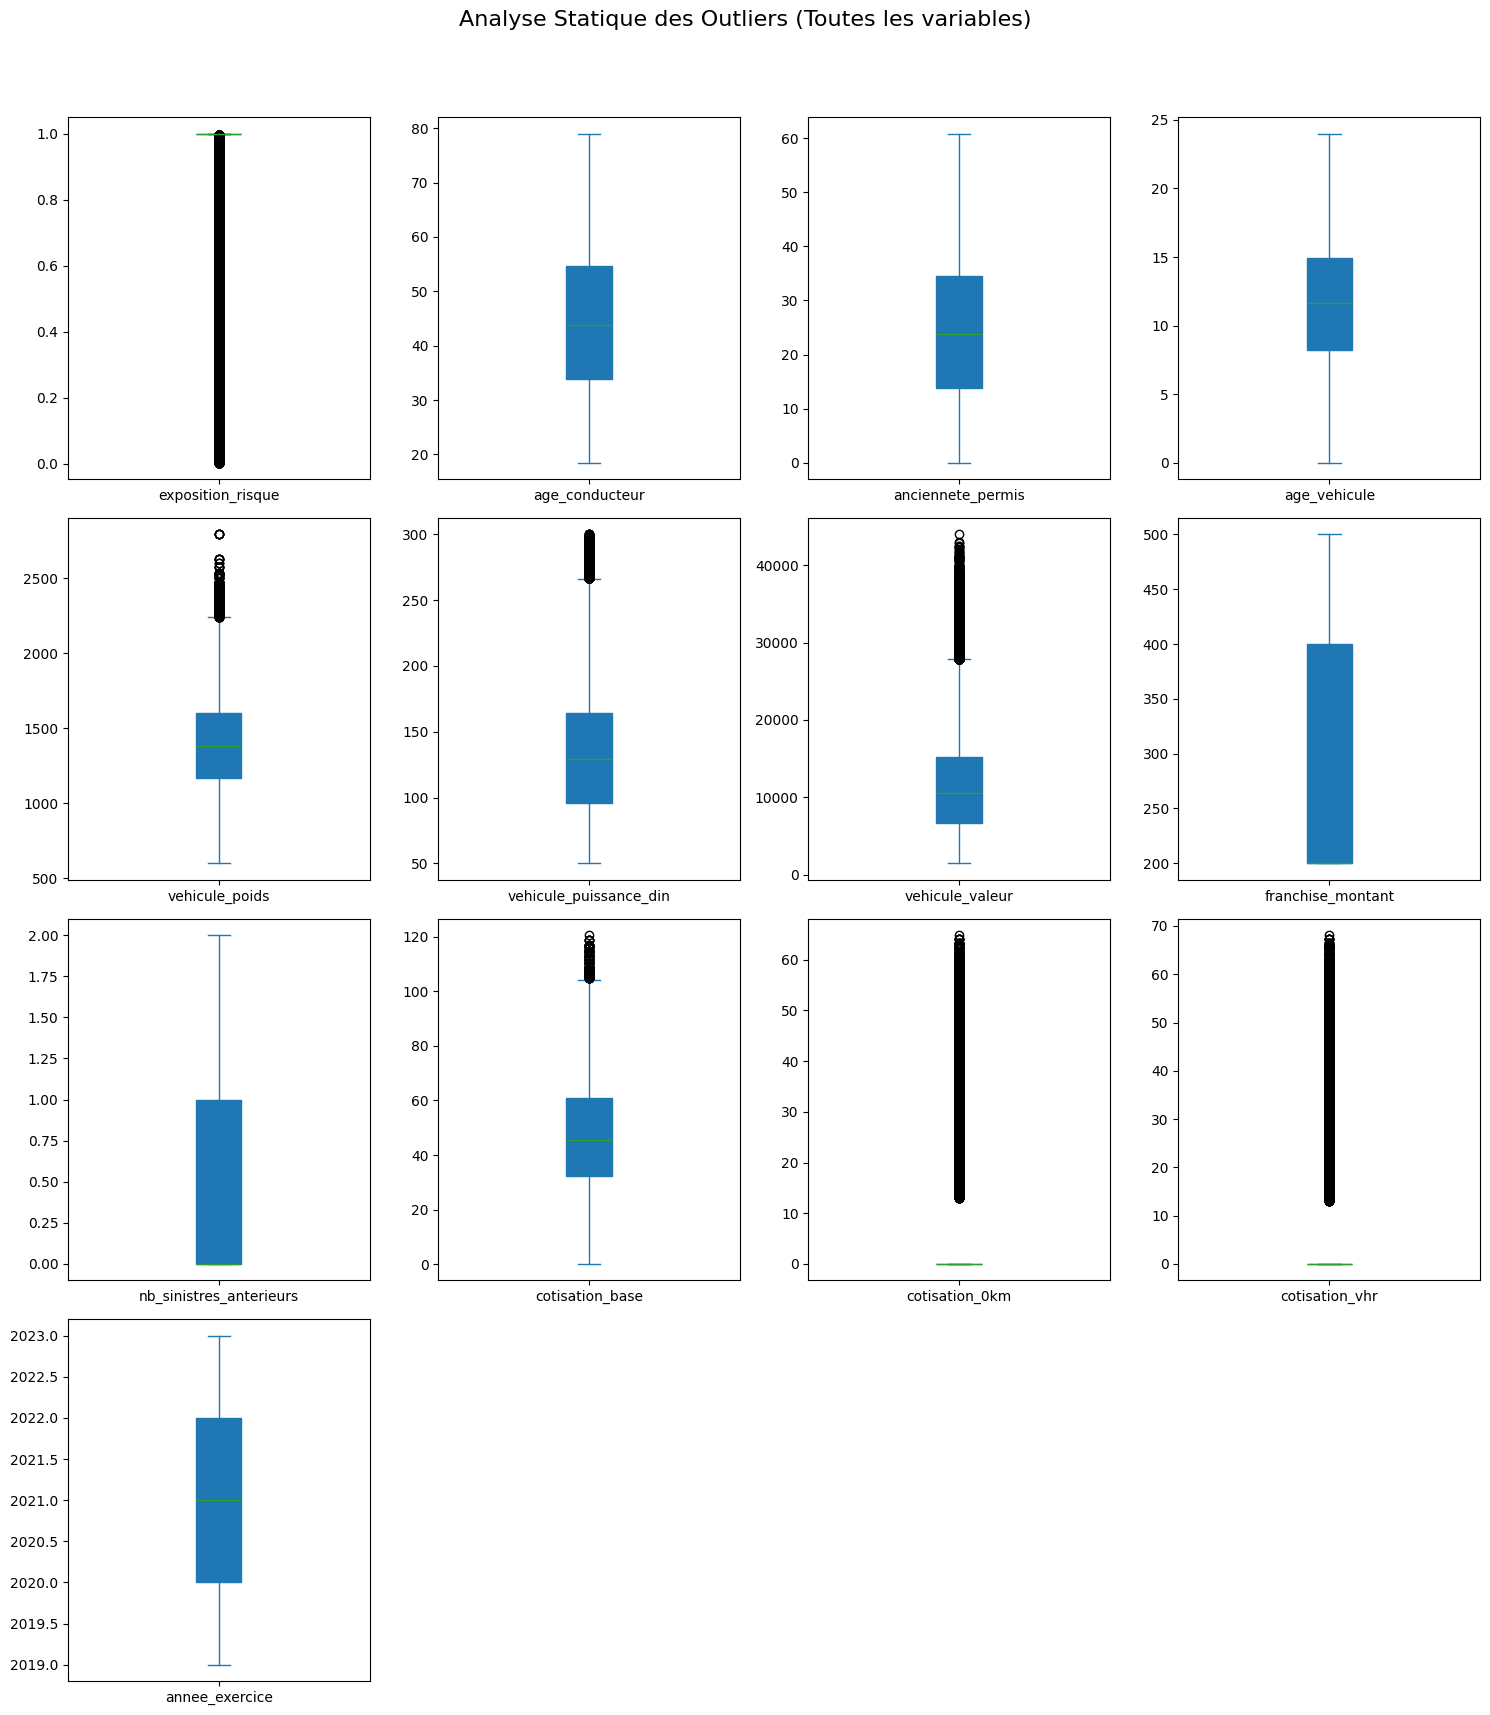

In [107]:
# Correction de la grille pour accueillir les 12 variables
df_prep[cols_numeriques].plot(
    kind='box', 
    subplots=True, 
    layout=(4, 4), # 4 lignes, 3 colonnes = 12 places
    figsize=(15, 18), # On augmente la hauteur (18) pour que ce soit lisible
    patch_artist=True
)

plt.suptitle("Analyse Statique des Outliers (Toutes les variables)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste pour ne pas chevaucher le titre
plt.show()

Après une analyse des différentes variables il ne semble pas y avoir besoin d'apporter de modification.

## 6. Conversion des dates et tests de cohérence
### 6.1 Conversion des dates
Les dates des données ne sont pas de type date il faut donc les convertir.

In [110]:
# Conversion des colonnes en objets Datetime
cols_dates = ['date_debut_situation', 'date_fin_situation']

for col in cols_dates:
    df_prep[col] = pd.to_datetime(df_prep[col], dayfirst=True, errors='coerce')

# Diagnostic après conversion (équivalent de glimpse)
print("TYPES DES COLONNES APRÈS CONVERSION :")
print(df_prep[cols_dates].dtypes)

print("\nAPERÇU DES DONNÉES :")
display(df_prep[cols_dates].head())

TYPES DES COLONNES APRÈS CONVERSION :
date_debut_situation    datetime64[us]
date_fin_situation      datetime64[us]
dtype: object

APERÇU DES DONNÉES :


C:\Users\taoro\AppData\Local\Temp\ipykernel_90732\3582837562.py:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_prep[col] = pd.to_datetime(df_prep[col], dayfirst=True, errors='coerce')


,date_debut_situation,date_fin_situation
0,2019-01-01,2019-12-31
1,2020-01-01,2020-12-31
2,2021-01-01,2021-12-31
3,2022-01-01,2022-12-31
4,2023-01-01,2023-12-31


### 6.2 Tests de cohérence sur les dates
On vérifie si les dates sont cohérentes entre elles.

#### Voici les informations que l’on a sur les dates :

In [112]:
summary_dates = df_prep[cols_dates].describe().T

print("RÉSUMÉ STATISTIQUE DES DATES ET DÉLAIS :")
display(summary_dates)

RÉSUMÉ STATISTIQUE DES DATES ET DÉLAIS :


,count,mean,min,25%,50%,75%,max
date_debut_situation,289346,2021-02-11 19:25:52.568896,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-12-12 00:00:00
date_fin_situation,301437,2022-02-09 23:10:33.696593,2019-12-31 00:00:00,2020-12-31 00:00:00,2021-12-31 00:00:00,2022-12-31 00:00:00,2023-12-31 00:00:00


Nous allons mettre en place un contrôle de cohérence et en cas de non respect nous allons remplacer les valeurs par des NA pour le moment. Le contrôle est : La date de fin ne peut pas être strictement inférieure à la date de début.


In [115]:
# --- TEST DE COHÉRENCE ---
# La date de fin ne peut pas être strictement inférieure à la date de début
mask_incoherent = df_prep['date_fin_situation'] < df_prep['date_debut_situation']

# Affichage du nombre d'erreurs avant correction
nb_erreurs = mask_incoherent.sum()
print(f"Nombre d'anomalies détectées (Fin < Début) : {nb_erreurs}")

# --- REMPLACEMENT PAR NA (NaT) ---
# On passe en NaT les dates de fin qui sont illogiques
df_prep.loc[mask_incoherent, 'date_fin_situation'] = pd.NaT

# --- RÉSUMÉ FINAL ---
print("\nVÉRIFICATION DES VALEURS MANQUANTES :")
print(df_prep[['date_debut_situation', 'date_fin_situation']].isnull().sum())

Nombre d'anomalies détectées (Fin < Début) : 0

VÉRIFICATION DES VALEURS MANQUANTES :
date_debut_situation    12091
date_fin_situation          0
dtype: int64


## 7. Détection et suppression des doublons
Certaines lignes peuvent être strictement identiques suite à des erreurs d’import ou de saisie.

In [117]:
df_doublons = df_prep[df_prep.duplicated(keep=False)]
print(f"Nombre de lignes concernées par des doublons : {len(df_doublons)}")

# 2. Comptage avant nettoyage
n_avant = len(df_prep)
print(f"Nombre total de lignes avant nettoyage : {n_avant}")

# 3. Suppression des doublons 
df_prep = df_prep.drop_duplicates()

# 4. Comptage après nettoyage
n_apres = len(df_prep)
print(f"Nombre total de lignes après nettoyage : {n_apres}")
print(f"Nombre de lignes uniques supprimées : {n_avant - n_apres}")

Nombre de lignes concernées par des doublons : 0
Nombre total de lignes avant nettoyage : 301437
Nombre total de lignes après nettoyage : 301437
Nombre de lignes uniques supprimées : 0


## 8. Analyse des données manquantes
Les valeurs manquantes peuvent provenir :

- d’erreurs de mesure

- d’informations non disponibles

- d’erreurs de saisie

Une analyse détaillée est donc nécessaire.

### 8.1 Résumé des valeurs manquantes
Voici les valeurs manquantes et la proportion quelle représente :

In [120]:
# 1. Calcul du nombre de NA par variable
n_miss = df_prep.isnull().sum()

# 2. Calcul du pourcentage de NA
pct_miss = (n_miss / len(df_prep)) * 100

# 3. Création du tableau de synthèse (équivalent miss_var_summary)
miss_var_summary = pd.DataFrame({
    'variable': n_miss.index,
    'n_miss': n_miss.values,
    'pct_miss': pct_miss.values
})

# 4. Tri par ordre décroissant de manquants
miss_var_summary = miss_var_summary.sort_values(by='n_miss', ascending=False).reset_index(drop=True)

print("RÉSUMÉ DES VARIABLES MANQUANTES :")
display(miss_var_summary)

RÉSUMÉ DES VARIABLES MANQUANTES :


,variable,n_miss,pct_miss
0,id3_sinistre_vhr,301437,100.000000
1,id3_sinistre_0km,301435,99.999337
2,id2_sinistre_vhr,301403,99.988721
3,id3_sinistre_base,301369,99.977441
4,id2_sinistre_0km,301335,99.966162
5,id1_sinistre_vhr,300472,99.679867
6,id2_sinistre_base,299885,99.485133
7,id1_sinistre_0km,298994,99.189549
8,id1_sinistre_base,272856,90.518417
9,date_debut_situation,12091,4.011120


### 8.2 Visualisation des valeurs manquantes
Pourcentage et localisation des valeurs manquantes

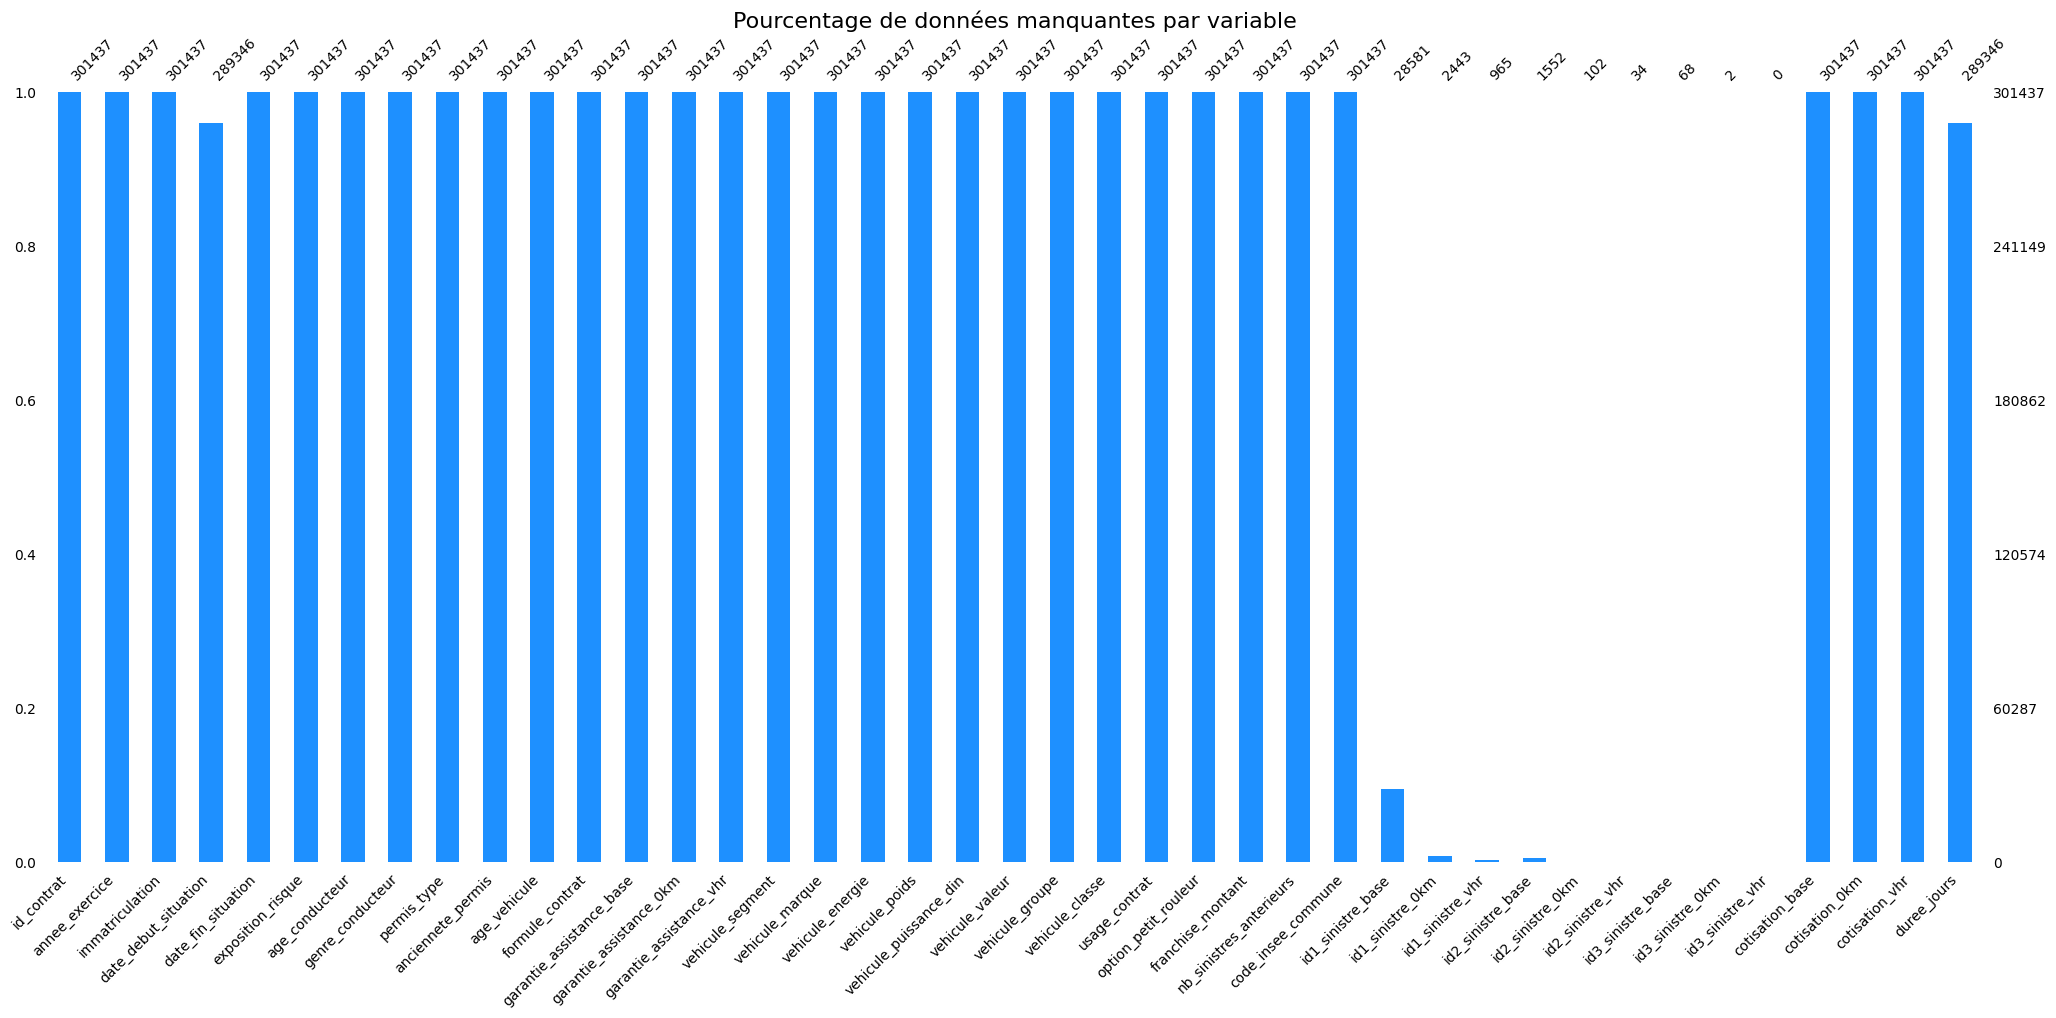

<Figure size 1000x600 with 0 Axes>

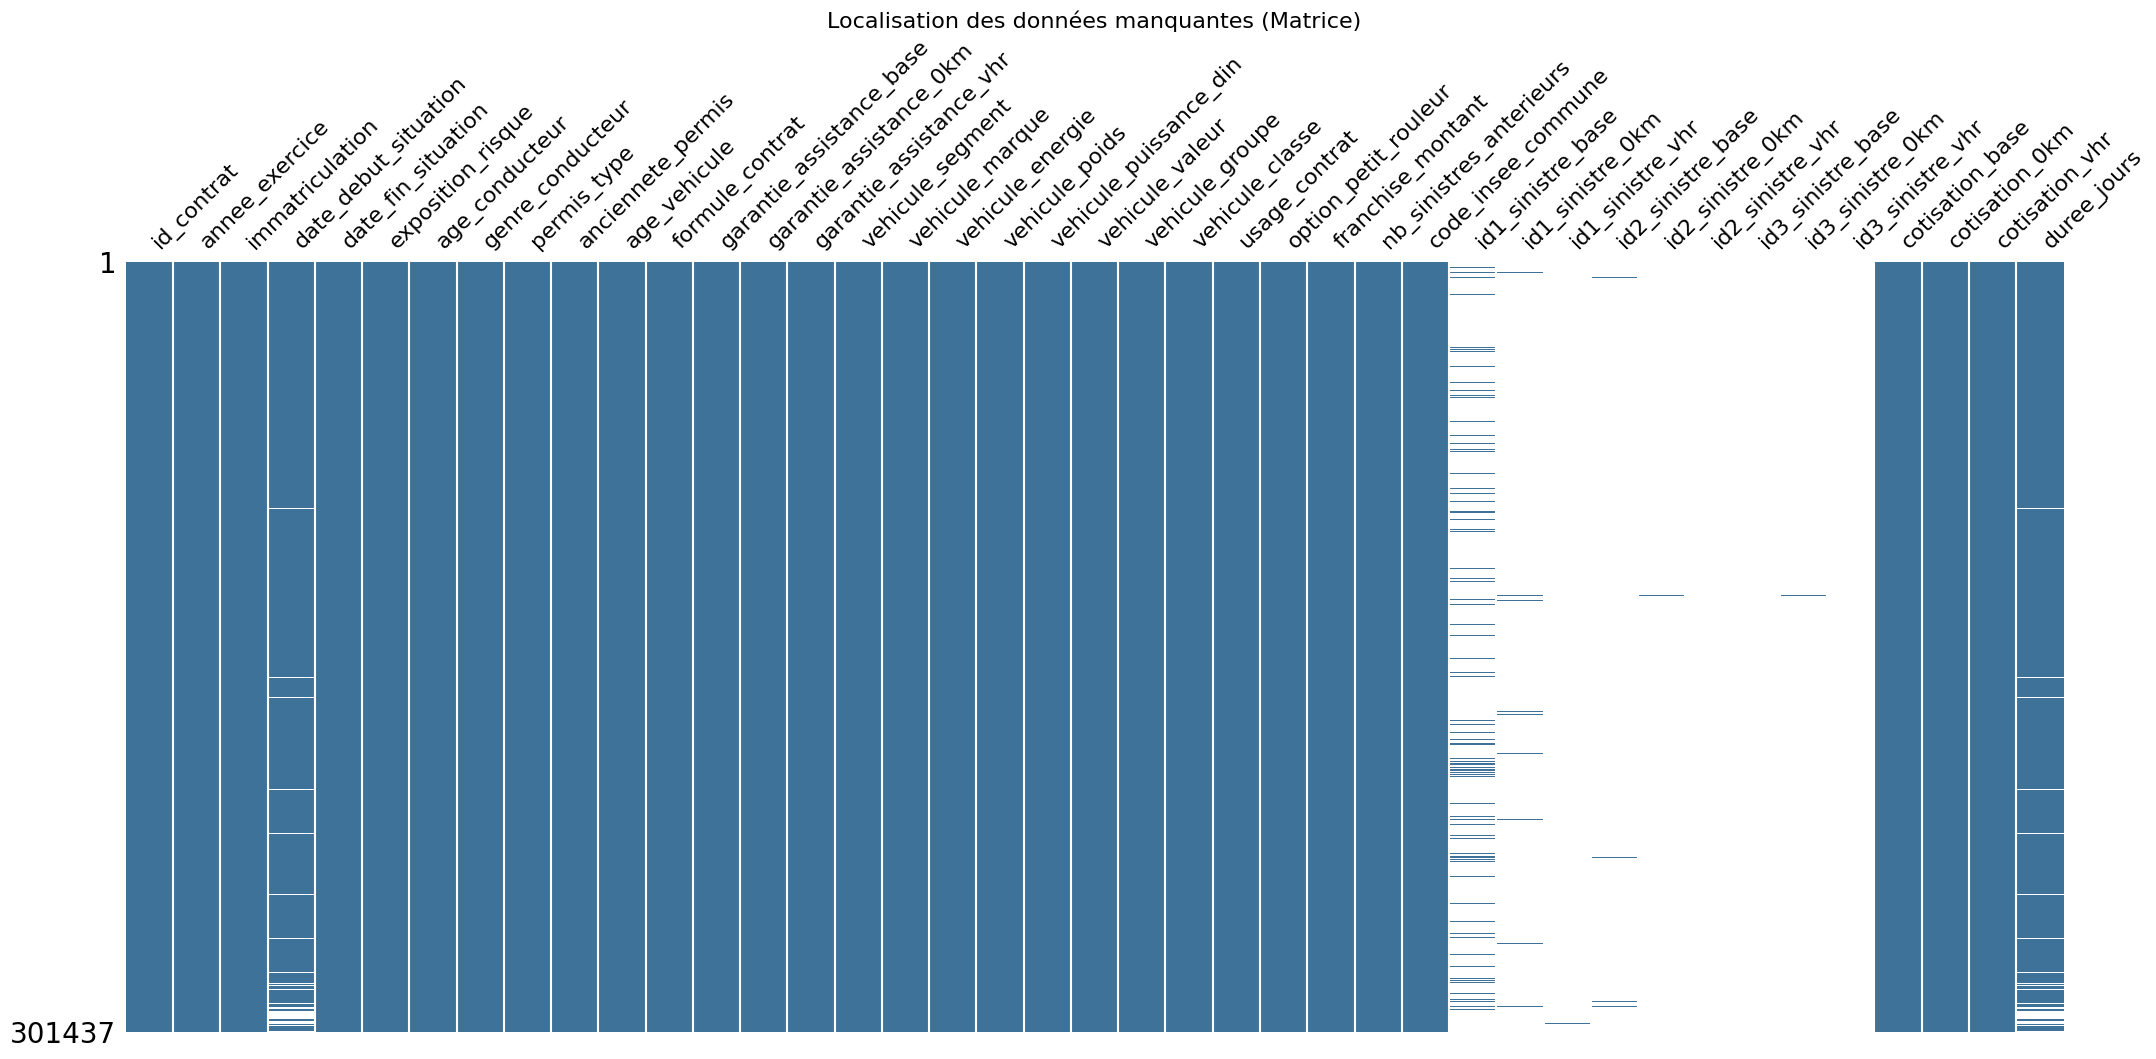

In [119]:
# msno.bar affiche le compte et le pourcentage en haut des barres
plt.figure(figsize=(10, 6))
msno.bar(df_prep, color="dodgerblue", fontsize=10)
plt.title("Pourcentage de données manquantes par variable", fontsize=16)
plt.show()

# msno.matrix montre exactement où se trouvent les trous dans le dataset
plt.figure(figsize=(10, 6))
msno.matrix(df_prep, sparkline=False, color=(0.25, 0.45, 0.6))
plt.title("Localisation des données manquantes (Matrice)", fontsize=16)
plt.show()

On laissera les date et les identifiants pour lesquels il manque la donnée tel quel car on ne pourra pas procédé par imputation et les supprimé reviendrais à supprimer trop de ligne. De plus le reste des informations peut être utile.

Ainsi, nous n'avons aucun travail d'imputation ou de suppression de ligne à faire car il ne manque aucune valeurs dans les variable qui ne sont pas de type date ou identifiant.

## Conclusion
Désormais le jeu de données obtenu est cohérent, propre et prêt pour l’analyse exploratoire et la modélisation statistique.

Dernière information sur la table nettoyé :

In [121]:
# On définit le DataFrame final
df_final = df_prep.copy()

# Nombre de lignes et colonnes (équivalent ncol et nrow)
print(f"Nombre de colonnes : {df_final.shape[1]}")
print(f"Nombre de lignes : {df_final.shape[0]}")

print("-" * 30)

# Équivalent de glimpse() : donne le type, les non-nuls et un aperçu
print("DERNIÈRE INFORMATION SUR LA TABLE NETTOYÉE :")
df_final.info()

# Aperçu des premières lignes
display(df_final.head())

Nombre de colonnes : 41
Nombre de lignes : 301437
------------------------------
DERNIÈRE INFORMATION SUR LA TABLE NETTOYÉE :
<class 'pandas.DataFrame'>
RangeIndex: 301437 entries, 0 to 301436
Data columns (total 41 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   id_contrat                301437 non-null  str           
 1   annee_exercice            301437 non-null  int64         
 2   immatriculation           301437 non-null  str           
 3   date_debut_situation      289346 non-null  datetime64[us]
 4   date_fin_situation        301437 non-null  datetime64[us]
 5   exposition_risque         301437 non-null  float64       
 6   age_conducteur            301437 non-null  float64       
 7   genre_conducteur          301437 non-null  str           
 8   permis_type               301437 non-null  str           
 9   anciennete_permis         301437 non-null  float64       
 10  age_vehicule 

,id_contrat,annee_exercice,immatriculation,date_debut_situation,date_fin_situation,exposition_risque,age_conducteur,genre_conducteur,permis_type,anciennete_permis,...,id2_sinistre_base,id2_sinistre_0km,id2_sinistre_vhr,id3_sinistre_base,id3_sinistre_0km,id3_sinistre_vhr,cotisation_base,cotisation_0km,cotisation_vhr,duree_jours
0,C002513884,2019,ME-6556-LY,2019-01-01,2019-12-31,1.0,39.52,H,Cond Accompagnée,18.68,...,NaN,NaN,NaN,NaN,NaN,NaN,21.01,0.0,0.0,364.0
1,C002513884,2020,ME-6556-LY,2020-01-01,2020-12-31,1.0,40.52,H,Cond Accompagnée,19.68,...,NaN,NaN,NaN,NaN,NaN,NaN,33.36,0.0,0.0,365.0
2,C002513884,2021,ME-6556-LY,2021-01-01,2021-12-31,1.0,41.52,H,Cond Accompagnée,20.68,...,NaN,NaN,NaN,NaN,NaN,NaN,43.62,0.0,0.0,364.0
3,C002513884,2022,ME-6556-LY,2022-01-01,2022-12-31,1.0,42.52,H,Cond Accompagnée,21.68,...,NaN,NaN,NaN,NaN,NaN,NaN,62.20,0.0,0.0,364.0
4,C002513884,2023,ME-6556-LY,2023-01-01,2023-12-31,1.0,43.52,H,Cond Accompagnée,22.68,...,NaN,NaN,NaN,NaN,NaN,NaN,75.00,0.0,0.0,364.0


In [124]:
# Résumé pour les variables numériques
print("RÉSUMÉ NUMÉRIQUE :")
display(df_final.describe().T)

# Résumé pour les variables catégorielles (Factor/Object)
print("\nRÉSUMÉ CATÉGORIEL :")
display(df_final.describe(include=['object', 'category']).T)

RÉSUMÉ NUMÉRIQUE :


,count,mean,min,25%,50%,75%,max,std
annee_exercice,301437.0,2021.112737,2019.0,2020.0,2021.0,2022.0,2023.0,1.427301
date_debut_situation,289346,2021-02-11 19:25:52.568896,2019-01-01 00:00:00,2020-01-01 00:00:00,2021-01-01 00:00:00,2022-01-01 00:00:00,2023-12-12 00:00:00,NaN
date_fin_situation,301437,2022-02-09 23:10:33.696593,2019-12-31 00:00:00,2020-12-31 00:00:00,2021-12-31 00:00:00,2022-12-31 00:00:00,2023-12-31 00:00:00,NaN
exposition_risque,301437.0,0.966932,0.002732,1.0,1.0,1.0,1.0,0.144753
age_conducteur,301437.0,44.693525,18.5,33.87,43.82,54.57,79.0,13.685469
anciennete_permis,301437.0,24.7373,0.0,13.86,23.85,34.58,60.86,13.659565
age_vehicule,301437.0,11.485966,0.0,8.18,11.64,14.96,24.0,4.879809
vehicule_poids,301437.0,1387.545716,600.0,1171.0,1385.0,1599.0,2793.0,308.583216
vehicule_puissance_din,301437.0,132.55881,50.0,96.0,129.0,164.0,300.0,47.501897
vehicule_valeur,301437.0,11466.762802,1476.01,6739.61,10588.37,15178.55,43975.97,6107.463141



RÉSUMÉ CATÉGORIEL :


C:\Users\taoro\AppData\Local\Temp\ipykernel_90732\878102804.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df_final.describe(include=['object', 'category']).T)


,count,unique,top,freq
id_contrat,301437,69688,C002513884,5
immatriculation,301437,69686,QJ-1327-QX,10
genre_conducteur,301437,2,H,180200
permis_type,301437,2,Traditionnel,226920
formule_contrat,301437,4,Mini,192558
garantie_assistance_base,301437,2,Non,260973
garantie_assistance_0km,301437,2,Non,260973
garantie_assistance_vhr,301437,2,absence,282195
vehicule_segment,301437,4,Citadine,120614
vehicule_marque,301437,14,Renault,60970


#### Export des données nettoyées
On export les données nettoyé en temps que csv “Contrat_clean.csv” dans le dossier data

In [125]:
# Exportation 
df_final.to_csv("data/Contrat_clean.csv", index=False, sep=",", encoding='utf-8')